# Textual Inversion on SD 3.5
Samsung DS^2 academy  - Creating Images with Generative AI


## Import packages

In [ ]:
from huggingface_hub import login
login()

In [ ]:
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from itertools import chain
from PIL import Image
import glob
import os

from diffusers import StableDiffusion3Pipeline
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Model ID and Other stuffs

In [ ]:
model_id = "stabilityai/stable-diffusion-3.5-medium"
placeholder_token = "<sks-dog>"
initializer_token = "dog"
learning_rate = 5e-4
num_train_epochs = 100
train_batch_size = 2
resolution = 256
output_dir = "textual_inversion_sd3_5_dog_final"
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16

## Download sample images

In [ ]:
instance_data_dir = "instance_images"
os.makedirs(instance_data_dir, exist_ok=True)

from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="diffusers/dog-example",
    repo_type="dataset",
    local_dir=instance_data_dir,
    ignore_patterns=[".gitattributes"],
)

image_files = [f for f in os.listdir(instance_data_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
assert len(image_files) > 0, f"'{instance_data_dir}' not found!"

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

## Check the training images

The images from `diffusers/dog-example` that the placeholder token is fit to.

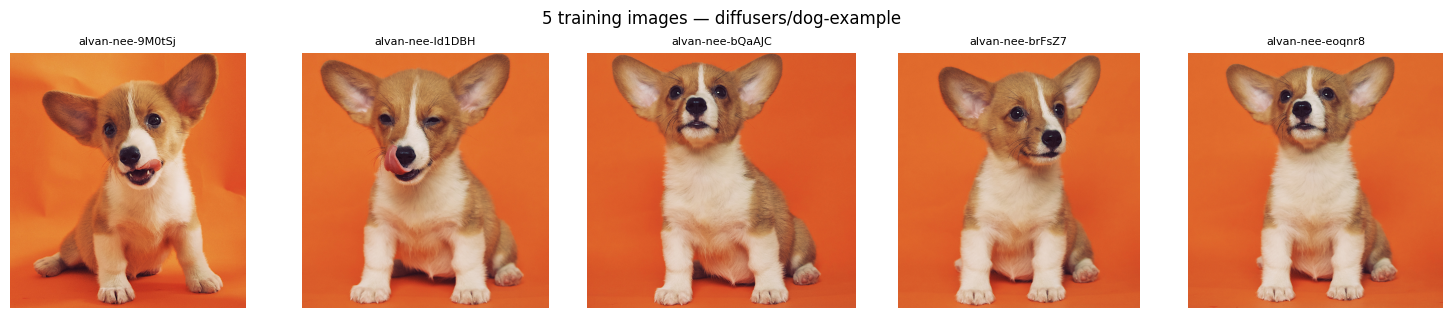

In [ ]:
image_paths = sorted(os.path.join(instance_data_dir, f) for f in image_files)

fig, axes = plt.subplots(1, len(image_paths), figsize=(3 * len(image_paths), 3.2))
for ax, path in zip(np.atleast_1d(axes), image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path)[:16], fontsize=8)
    ax.axis("off")
fig.suptitle(f"{len(image_paths)} training images — diffusers/dog-example")
fig.tight_layout()
plt.show()

## SD3 pipeline load

T5-XXL (`text_encoder_3`) is not loaded. On its own it is 4.76B parameters —
9.5 GiB in bf16 — which pushes the weights alone to 15.4 GiB and OOMs a 15 GB
GPU before training even starts.

In [ ]:
pipe = StableDiffusion3Pipeline.from_pretrained(
    model_id,
    text_encoder_3=None,
    tokenizer_3=None,
    torch_dtype=torch_dtype,
)
tokenizer_one, tokenizer_two = pipe.tokenizer, pipe.tokenizer_2
text_encoder_one, text_encoder_two = pipe.text_encoder, pipe.text_encoder_2
vae, transformer, scheduler = pipe.vae, pipe.transformer, pipe.scheduler

model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

## Tokenizer load / Prep to use Placeholder token :Learnable token

In [ ]:
text_encoders_list = [text_encoder_one, text_encoder_two]
tokenizers_list = [tokenizer_one, tokenizer_two]
for tokenizer in tokenizers_list: tokenizer.add_tokens(placeholder_token)

placeholder_token_id_one = tokenizer_one.convert_tokens_to_ids(placeholder_token)
initializer_token_id_one = tokenizer_one.convert_tokens_to_ids(initializer_token)
placeholder_token_id_two = tokenizer_two.convert_tokens_to_ids(placeholder_token)
initializer_token_id_two = tokenizer_two.convert_tokens_to_ids(initializer_token)

for encoder, tokenizer, p_id, i_id in [(text_encoder_one, tokenizer_one, placeholder_token_id_one, initializer_token_id_one), (text_encoder_two, tokenizer_two, placeholder_token_id_two, initializer_token_id_two)]:
    encoder.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        token_embeds = encoder.get_input_embeddings().weight.data
        token_embeds[p_id] = token_embeds[i_id].clone()

for encoder, tokenizer in zip(text_encoders_list, tokenizers_list):
    encoder.text_model.eos_token_id = tokenizer.eos_token_id


[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


## To train the tokens -> need to make the input_embedding layer trainable and other layers frozen

In [ ]:
vae.requires_grad_(False); transformer.requires_grad_(False)
for encoder in text_encoders_list:
    encoder.requires_grad_(False)
    encoder.get_input_embeddings().requires_grad_(True)

params_to_train = chain(
    text_encoder_one.get_input_embeddings().parameters(),
    text_encoder_two.get_input_embeddings().parameters(),
)

## Dataset declare to get the small number of train dataset

In [ ]:
class TextualInversionDataset(Dataset):
    def __init__(self, data_root, size, placeholder_prompt):
        self.data_root = data_root
        self.size = size
        self.placeholder_prompt = placeholder_prompt
        self.image_paths = sorted(glob.glob(os.path.join(self.data_root, "*.jpg")) + glob.glob(os.path.join(self.data_root, "*.jpeg")))
        self.image_transforms = transforms.Compose([transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR), transforms.CenterCrop(size), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        return {"pixel_values": self.image_transforms(image), "prompt": self.placeholder_prompt}

## Dataloader and optimizer

In [ ]:
vae.to(device); transformer.to(device)

# 학습 대상인 text encoder만 fp32로 둔다.
text_encoder_one.to(device, dtype=torch.float32); text_encoder_two.to(device, dtype=torch.float32)
train_prompt = f"a photo of a {placeholder_token}"
train_dataset = TextualInversionDataset(instance_data_dir, resolution, train_prompt)
train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
optimizer = torch.optim.AdamW(params_to_train, lr=learning_rate)

steps_per_epoch = len(train_dataloader)
print(f"{len(train_dataset)} images / batch {train_batch_size} "
      f"-> {steps_per_epoch} steps per epoch, "
      f"{num_train_epochs * steps_per_epoch} steps total")

5 images / batch 2 -> 3 steps per epoch, 300 steps total


## Train loop

In [ ]:
loss_history = []
total_steps = num_train_epochs * len(train_dataloader)

orig_embeds = [enc.get_input_embeddings().weight.data.clone() for enc in text_encoders_list]
index_no_updates = []
for enc, p_id in zip(text_encoders_list, [placeholder_token_id_one, placeholder_token_id_two]):
    keep = torch.ones(enc.get_input_embeddings().weight.shape[0], dtype=torch.bool)
    keep[p_id] = False
    index_no_updates.append(keep)

text_encoder_one.train(); text_encoder_two.train()
progress_bar = tqdm(total=total_steps, desc="Training")

for epoch in range(num_train_epochs):
    for batch in train_dataloader:
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device, dtype=torch_dtype)).latent_dist.sample()
            clean_latents = (latents - vae.config.shift_factor) * vae.config.scaling_factor

        noise = torch.randn_like(clean_latents)
        bsz = clean_latents.shape[0]
        sigmas = torch.rand(bsz, device=clean_latents.device, dtype=torch_dtype)
        s_view = sigmas.view(-1, 1, 1, 1)
        noisy_latents = (1 - s_view) * clean_latents + s_view * noise
        target = noise - clean_latents
        timesteps = sigmas.float() * scheduler.config.num_train_timesteps

        prompt_embeds_output, _, pooled_prompt_embeds_output, _ = pipe.encode_prompt(
            prompt=batch["prompt"],
            prompt_2=batch["prompt"],
            prompt_3=None,
            device=device,
            num_images_per_prompt=1,
            do_classifier_free_guidance=False
        )

        prompt_embeds = prompt_embeds_output.to(dtype=torch_dtype)
        pooled_prompt_embeds = pooled_prompt_embeds_output.to(dtype=torch_dtype)

        model_pred = transformer(hidden_states=noisy_latents, timestep=timesteps, encoder_hidden_states=prompt_embeds, pooled_projections=pooled_prompt_embeds).sample
        loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
        loss.backward(); optimizer.step(); optimizer.zero_grad()

        with torch.no_grad():
            for enc, orig, keep in zip(text_encoders_list, orig_embeds, index_no_updates):
                enc.get_input_embeddings().weight[keep] = orig[keep]

        loss_history.append(loss.item())
        progress_bar.update(1)
        progress_bar.set_postfix(epoch=f"{epoch + 1}/{num_train_epochs}", loss=f"{loss.item():.4f}")

progress_bar.close()


os.makedirs(output_dir, exist_ok=True)
learned_embed_one = text_encoder_one.get_input_embeddings().weight[placeholder_token_id_one].detach().cpu()
learned_embed_two = text_encoder_two.get_input_embeddings().weight[placeholder_token_id_two].detach().cpu()
torch.save({"placeholder_token": placeholder_token, "clip_l": learned_embed_one, "clip_g": learned_embed_two}, os.path.join(output_dir, "learned_embeds.bin"))

del pipe, vae, transformer, text_encoder_one, text_encoder_two
torch.cuda.empty_cache()

Training:   0%|          | 0/300 [00:00<?, ?it/s]

# INFERENCE

Note that use of good seeds are important -> If re-sample, we can get either worse or better result

In [ ]:
import os
import gc
import torch

from diffusers import StableDiffusion3Pipeline

try:
    del pipe, vae, transformer, text_encoder_one, text_encoder_two
    gc.collect()
    torch.cuda.empty_cache()
except NameError:
    pass

## Reload the pipeline for inference

In [ ]:
model_id = "stabilityai/stable-diffusion-3.5-medium"
output_dir = "textual_inversion_sd3_5_dog_final"
device = "cuda" if torch.cuda.is_available() else "cpu"
resolution = 256
torch_dtype = torch.float16   # T4(Turing)는 bf16 미지원

inference_pipe = StableDiffusion3Pipeline.from_pretrained(
    model_id,
    text_encoder_3=None,
    tokenizer_3=None,
    torch_dtype=torch_dtype,
).to(device)

for enc in [inference_pipe.text_encoder,
            inference_pipe.text_encoder_2]:
    enc.eval()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

## Inference (Sampling)

  0%|          | 0/28 [00:00<?, ?it/s]

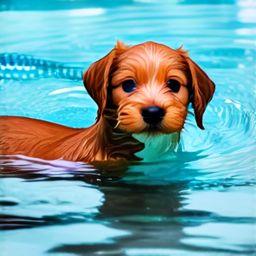

In [ ]:
state_dict = torch.load(os.path.join(output_dir, "learned_embeds.bin"))
token = state_dict["placeholder_token"]
embeds_l = state_dict["clip_l"]
embeds_g = state_dict["clip_g"]

text_encoders = [inference_pipe.text_encoder, inference_pipe.text_encoder_2]
tokenizers = [inference_pipe.tokenizer, inference_pipe.tokenizer_2]
learned_embeds = [embeds_l, embeds_g]

for te, tok, em in zip(text_encoders, tokenizers, learned_embeds):
    num_added_tokens = tok.add_tokens(token)
    te.resize_token_embeddings(len(tok))
    token_id = tok.convert_tokens_to_ids(token)

    with torch.no_grad():
        te.get_input_embeddings().weight.data[token_id] = em.to(te.device)

for te, tok in zip(text_encoders, tokenizers):
    te.text_model.eos_token_id = tok.eos_token_id

inference_prompt = f"a high-quality photo of a {token} swimming in a pool"

image = inference_pipe(
    prompt=inference_prompt,
    prompt_2=inference_prompt,
    num_inference_steps=28,
    guidance_scale=7,
    height=resolution,
    width=resolution,
).images[0]

display(image)

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

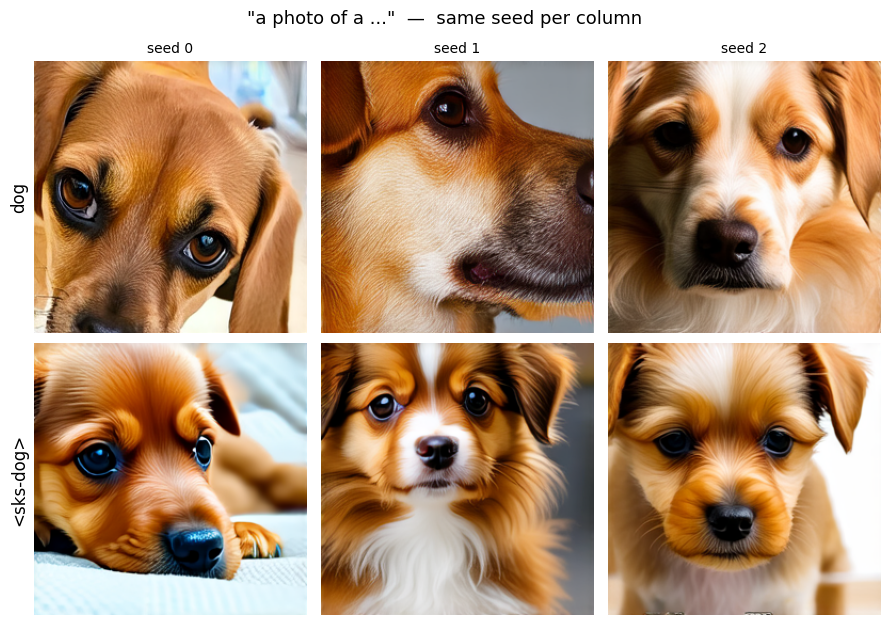

In [ ]:
import matplotlib.pyplot as plt

SEEDS    = [0, 1, 2]
TEMPLATE = "a photo of a {}"
SUBJECTS = ["dog", token]

rows = []
for subject in SUBJECTS:
    prompt = TEMPLATE.format(subject)
    imgs = []
    for s in SEEDS:
        gen = torch.Generator(device=inference_pipe.device).manual_seed(s)
        imgs.append(
            inference_pipe(
                prompt=prompt,
                prompt_2=prompt,
                num_inference_steps=28,
                guidance_scale=7,
                generator=gen,
                width=resolution,
                height=resolution,
            ).images[0]
        )
    rows.append((subject, imgs))

fig, axes = plt.subplots(len(SUBJECTS), len(SEEDS),
                         figsize=(3.0 * len(SEEDS), 3.2 * len(SUBJECTS)))
for r, (subject, imgs) in enumerate(rows):
    for c, img in enumerate(imgs):
        ax = axes[r][c]
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(f"seed {SEEDS[c]}", fontsize=10)
    axes[r][0].set_ylabel(subject, fontsize=12)

fig.suptitle(f'"{TEMPLATE.format("...")}"  —  same seed per column', fontsize=13)
fig.tight_layout()
plt.show()